# TASK 1

## LIBRARIES

In [25]:
import random
import heapq
import itertools
import numpy as np
from scipy.interpolate import interp1d
from typing import List
import matplotlib.pyplot as plt
from scipy import stats

## CLASSES

### TASK

In [26]:
class Task:
    def __init__(self, arrival_time: float, task_type: str, L: float, C: float, D_max: float):
        self.arrival_time = arrival_time
        self.task_type = task_type
        self.L = L
        self.C = C
        self.D_max = D_max

### MEASURE

In [27]:
class Measure:
    def __init__(self):
        # Dati discreti
        self.processed_tasks = 0
        self.cumulative_delay = 0.0
        self.qos_met = 0
        self.delay_list = []
        
        # Dati continui (Aree per l'integrale)
        self.area_queue = 0.0
        self.area_server_busy = 0.0
        self.last_update_time = 0.0

    def update_time_averages(self, current_time: float, queue_length: int, is_busy: bool) -> None:
        time_delta = current_time - self.last_update_time
        if time_delta > 0:
            self.area_queue += time_delta * queue_length
            self.area_server_busy += time_delta * (1 if is_busy else 0)
        self.last_update_time = current_time

    def record_task_completion(self, delay: float, d_max: float) -> None:
        self.processed_tasks += 1
        self.cumulative_delay += delay
        self.delay_list.append(delay)
        if delay <= d_max:
            self.qos_met += 1

    def reset_statistics(self, current_time: float) -> None:
        self.processed_tasks = 0
        self.cumulative_delay = 0.0
        self.qos_met = 0
        self.delay_list.clear()
        
        self.area_queue = 0.0
        self.area_server_busy = 0.0
        self.last_update_time = current_time

    @property
    def average_delay(self) -> float:
        return self.cumulative_delay / self.processed_tasks if self.processed_tasks > 0 else 0.0

### SENSING NODE

In [28]:
class SensingNode:
    def __init__(self, node_id: int, f_loc: float, lambda_rate: float):
        self.node_id = node_id
        self.f_loc = f_loc
        self.lambda_rate = lambda_rate
        
        self.queue = []
        self.server_busy = False
        self.stats = Measure()

## FUNCTIONS

### TASK GENERATION

In [29]:
def task_generation(time, FES, node, alpha, params_Ks, params_Kt, event_counter):
    # 1. Arrivi Esponenziali (Era già corretto!)
    inter_arrival = random.expovariate(node.lambda_rate)
    heapq.heappush(FES, (time + inter_arrival, next(event_counter), 'task_generation', node, alpha, params_Ks, params_Kt, event_counter))
    
    # Generazione Task
    if random.random() <= alpha:
        task = Task(time, "K_s", params_Ks['L'], params_Ks['C'], params_Ks['D_max'])
    else:
        task = Task(time, "K_t", params_Kt['L'], params_Kt['C'], params_Kt['D_max'])
        
    node.stats.update_time_averages(time, len(node.queue), 1 if node.server_busy else 0)
    
    if not node.server_busy:
        node.server_busy = True
        
        # LA MODIFICA M/M/1: Il servizio ora è esponenziale!
        actual_C = random.expovariate(1.0 / task.C)
        T_s = actual_C / node.f_loc
        
        heapq.heappush(FES, (time + T_s, next(event_counter), 'local_departure', node, task, event_counter))
    else:
        node.queue.append(task)

def local_departure(time, FES, node, task, event_counter):
    node.stats.update_time_averages(time, len(node.queue), 1 if node.server_busy else 0)
    
    delay = time - task.arrival_time
    node.stats.record_task_completion(delay, task.D_max)
    
    if len(node.queue) > 0:
        next_task = node.queue.pop(0)
        
        # LA MODIFICA M/M/1 anche qui
        actual_C = random.expovariate(1.0 / next_task.C)
        T_s = actual_C / node.f_loc
        
        heapq.heappush(FES, (time + T_s, next(event_counter), 'local_departure', node, next_task, event_counter))
    else:
        node.server_busy = False

### LOCAL DEPARTURE

In [30]:
def local_departure(time, FES, node, task, event_counter):
    node.stats.update_time_averages(time, len(node.queue), 1 if node.server_busy else 0)
    
    delay = time - task.arrival_time
    node.stats.record_task_completion(delay, task.D_max)
    
    if len(node.queue) > 0:
        next_task = node.queue.pop(0)
        
        # LA MODIFICA M/M/1 anche qui
        actual_C = random.expovariate(1.0 / next_task.C)
        T_s = actual_C / node.f_loc
        
        heapq.heappush(FES, (time + T_s, next(event_counter), 'local_departure', node, next_task, event_counter))
    else:
        node.server_busy = False

### RUN SIM MODE

In [31]:
def run_sim_node(tasks_to_complete, lambda_rate, f_loc, params_Ks, params_Kt=None, alpha=1.0, seed=42):
    random.seed(seed)
    event_counter = itertools.count() 
    FES = []
    
    node = SensingNode(node_id=1, f_loc=f_loc, lambda_rate=lambda_rate)
    
    # Innesco del sistema a vuoto
    heapq.heappush(FES, (0.0, next(event_counter), 'task_generation', node, alpha, params_Ks, params_Kt, event_counter))
    
    time_points = [0.0]
    queue_lengths = [0]
    server_status = [0.0] 
    
    current_time = 0.0
    
    while len(node.stats.delay_list) < tasks_to_complete and len(FES) > 0:
        event_time, _, event_type, *args = heapq.heappop(FES)
        current_time = event_time
        
        if event_type == 'task_generation':
            task_generation(current_time, FES, args[0], args[1], args[2], args[3], args[4])
        elif event_type == 'local_departure':
            local_departure(current_time, FES, args[0], args[1], args[2])
            
        time_points.append(current_time)
        queue_lengths.append(len(node.queue))
        server_status.append(1.0 if node.server_busy else 0.0)
        
    return node.stats.delay_list, time_points, queue_lengths, server_status

### RUN MULTIPLE SIMS

In [32]:
def run_multiple_sims(num_runs, tasks_to_complete, time_limit, lambda_rate, f_loc, params_Ks, params_Kt=None, alpha=1.0):
    all_delays = np.zeros((num_runs, tasks_to_complete))
    
    # Griglia temporale fissa per le metriche continue (10 campioni/s)
    num_samples = int(time_limit * 10) 
    time_grid = np.linspace(0, time_limit, num_samples)
    
    sum_queues = np.zeros(num_samples)
    sum_utils = np.zeros(num_samples)
    
    for i in range(num_runs):
        delays, t_pts, q_lens, s_stats = run_sim_node(
            tasks_to_complete=tasks_to_complete, 
            lambda_rate=lambda_rate, 
            f_loc=f_loc, 
            params_Ks=params_Ks, 
            params_Kt=params_Kt, 
            alpha=alpha, 
            seed=(42+i)
        )
        
        all_delays[i, :] = delays[:tasks_to_complete]
        
        # Interpolazione a gradini
        f_q = interp1d(t_pts, q_lens, kind='previous', fill_value="extrapolate")
        f_s = interp1d(t_pts, s_stats, kind='previous', fill_value="extrapolate")
        
        sum_queues += f_q(time_grid)
        sum_utils += f_s(time_grid)
        
    # Calcolo delle Ensemble Averages
    avg_queue = sum_queues / num_runs
    avg_utilization = sum_utils / num_runs
    avg_delay = np.mean(all_delays, axis=0) 
    
    return time_grid, avg_queue, avg_utilization, avg_delay, all_delays

### PLOT AVG DELAY

In [33]:
def plot_avg_delay(avg_delay, lambda_rate, mu_rate, zoom_tasks=None):
    plt.figure(figsize=(10, 4))
    task_indices = range(1, len(avg_delay) + 1)
    
    plt.plot(task_indices, avg_delay, color='red', linewidth=1.5, label='Evoluzione Transitorio')
    
    media_effettiva = np.mean(avg_delay)
    plt.axhline(y=media_effettiva, color='orange', linestyle='-.', linewidth=2, 
                label=f'Media Globale ({media_effettiva:.3f} s)')
    
    if lambda_rate < mu_rate:
        # FORMULA M/M/1 Ripristinata
        delay_teorico = 1.0 / (mu_rate - lambda_rate)
        plt.axhline(y=delay_teorico, color='black', linestyle='--', 
                    label=f'Teorico a Regime ({delay_teorico:.3f} s)')
        
    plt.title("Ritardo Medio per Task (M/M/1)")
    plt.xlabel("Indice Task")
    plt.ylabel("Ritardo Medio [s]")
    if zoom_tasks is not None:
        plt.xlim(0, zoom_tasks)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc="lower right")
    plt.show()

### PLOT AVG QUEUE

In [34]:
def plot_avg_queue(time_grid, avg_queue, lambda_rate, mu_rate, zoom_time=None):
    plt.figure(figsize=(10, 4))
    plt.plot(time_grid, avg_queue, color='blue', linewidth=1.5, label='Evoluzione Transitorio')
    
    media_effettiva = np.mean(avg_queue)
    plt.axhline(y=media_effettiva, color='orange', linestyle='-.', linewidth=2, 
                label=f'Media Globale ({media_effettiva:.2f} task)')
    
    if lambda_rate < mu_rate:
        # FORMULA M/M/1 Ripristinata
        
        queue_teorica = lambda_rate**2 / (mu_rate * (mu_rate - lambda_rate))
        plt.axhline(y=queue_teorica, color='black', linestyle='--', 
                    label=f'Teorico a Regime ({queue_teorica:.2f} task)')

    plt.title("Evoluzione nel Tempo dei Task nel Sistema (M/M/1)")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Numero Medio di Task")
    if zoom_time is not None:
        plt.xlim(0, zoom_time)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc="lower right")
    plt.show()

### PLOT AVG UTILIZATION

In [35]:
def plot_avg_utilization(time_grid, avg_utilization, lambda_rate, mu_rate, zoom_time=None):
    plt.figure(figsize=(10, 4))
    
    plt.plot(time_grid, avg_utilization, color='green', linewidth=1.5, label='Evoluzione Transitorio')
    
    media_effettiva = np.mean(avg_utilization)
    plt.axhline(y=media_effettiva, color='orange', linestyle='-.', linewidth=2, 
                label=f'Media Globale ({media_effettiva:.2f})')
    
    rho_teorico = (lambda_rate / mu_rate)
    plt.axhline(y=rho_teorico, color='black', linestyle='--', 
                label=f'rho Teorico ({rho_teorico/(1-rho_teorico):.2f})')
    
    plt.title("Utilizzo Medio del Server")
    plt.xlabel("Tempo [s]")
    plt.ylabel("Probabilità Server Occupato")
    
    # Impostiamo i limiti Y di base, ma li manteniamo compatibili con lo zoom
    plt.ylim(-0.05, 1.05) 
    
    # --- ZOOM ---
    if zoom_time is not None:
        plt.xlim(0, zoom_time)
        
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc="lower right")
    plt.show()

### ANALYZE WARMUP

In [36]:
def analyze_warmup(ensemble_delays, max_discard_percent=0.60, k_star=300):
    n = len(ensemble_delays)
    
    # Calcolo della media globale (per il calcolo della variazione relativa)
    x_bar = np.mean(ensemble_delays)
    
    # LA TUA NUOVA LINEA: Media a regime escludendo i primi k_star task
    x_bar_k_star = np.mean(ensemble_delays[k_star:])
    
    max_k = int(n * max_discard_percent)
    k_values = np.arange(1, max_k + 1)
    
    x_bar_k_list = []
    R_k_list = []
    
    for k in k_values:
        x_bar_k = np.mean(ensemble_delays[k:])
        x_bar_k_list.append(x_bar_k)
        R_k = (x_bar_k - x_bar) / x_bar
        R_k_list.append(R_k)
        
    # --- 1° GRAFICO: Media Troncata ---
    plt.figure(figsize=(10, 5))
    plt.plot(k_values, x_bar_k_list, color='purple', linewidth=2, label='Media Troncata ($\\bar{X}_k$)')
    
    # Tracciamo SOLO la linea orizzontale a regime (scartando i primi 300)
    plt.axhline(y=x_bar_k_star, color='green', linestyle='--', linewidth=2, 
                label=f'Media a regime ($\\bar{{X}}_{{{k_star}}}$) = {x_bar_k_star:.3f} s')
    
    plt.title(f"Media Troncata (scarto massimo {max_discard_percent*100:.0f}%)", fontsize=14)
    plt.xlabel("Numero di campioni scartati ($k$)", fontsize=12)
    plt.ylabel("Media Troncata [s]", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- 2° GRAFICO: Variazione Relativa ---
    plt.figure(figsize=(10, 5))
    plt.plot(k_values, R_k_list, color='darkorange', linewidth=2)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Riferimento Zero') 
    plt.title(f"Variazione Relativa rispetto alla media globale", fontsize=14)
    plt.xlabel("Numero di campioni scartati ($k$)", fontsize=12)
    plt.ylabel("Variazione Relativa ($R_k$)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()




### PERFORM STATISTICAL ANALYSIS

In [37]:
def perform_statistical_analysis(all_delays, k_star=75, confidence=0.95):
    """
    all_delays: Matrice 50 righe x 20.000 colonne (risultato di run_multiple_sims)
    k_star: Il numero di task da scartare per il warm-up
    """
    
    # 1. Pulizia: rimuoviamo il transitorio da ogni singola replica
    # Trasformiamo in array per usare lo slicing (righe=run, colonne=task)
    data = np.array(all_delays)
    trimmed_data = data[:, k_star:] 
    
    # 2. Otteniamo la stima della media per ogni singola replica (Ensemble)
    # Calcoliamo la media di ogni riga (axis=1)
    run_means = np.mean(trimmed_data, axis=1)
    
    # 3. Calcolo statistico dell'intervallo
    n = len(run_means)
    mean_of_means = np.mean(run_means)
    std_err = stats.sem(run_means) # Calcola S / sqrt(N)
    
    # Valore critico t di Student
    h = std_err * stats.t.ppf((1 + confidence) / 2, n - 1)
    
    lower_bound = mean_of_means - h
    upper_bound = mean_of_means + h
    
    # Output dei risultati
    print("-" * 40)
    print("RISULTATI ANALISI STATISTICA (A REGIME)")
    print("-" * 40)
    print(f"Repliche indipendenti: {n}")
    print(f"Warm-up rimosso:       {k_star} task")
    print(f"Media stimata:         {mean_of_means:.4f} s")
    print(f"Intervallo Conf.{confidence*100:.0f}%: [{lower_bound:.4f}, {upper_bound:.4f}] s")
    print(f"Margine di errore:     ±{h:.4f} s")
    print("-" * 40)
    
    return mean_of_means, lower_bound, upper_bound

### RUN PERFOMANCE ANALYSIS

In [38]:
def run_performance_analysis(lambdas, mu, num_runs, tasks, params, k_star=75):
    results = []
    
    for lmb in lambdas:
        print(f"Analisi in corso per Lambda = {lmb} (Rho = {lmb/mu:.2f})...")
        
        # 1. Esegui la simulazione per questo carico
        # Nota: assumiamo che run_multiple_sims restituisca anche le code medie
        _, avg_q_all, _, _, all_delays = run_multiple_sims(
            num_runs=num_runs, 
            tasks_to_complete=tasks, 
            time_limit=200.0, 
            lambda_rate=lmb, 
            f_loc=1.0,  # Assumiamo f_loc = 1.0 per semplicità
            params_Ks=params,  # Parametri fittizi
            alpha=1.0
        )
        
        # 2. Analisi Ritardo (con IC)
        mean_d, lb_d, ub_d = perform_statistical_analysis(all_delays, k_star=k_star)
        
        # 3. Analisi Coda (media a regime delle code)
        # Rimuoviamo il warm-up anche dalle code (avg_q_all è già media di ensemble)
        steady_state_queue = np.mean(avg_q_all[k_star:])
        
        results.append({
            'lambda': lmb,
            'rho': lmb/mu,
            'mean_delay': mean_d,
            'lb_delay': lb_d,
            'ub_delay': ub_d,
            'mean_queue': steady_state_queue
        })
        
    return results

## 1.a

Parametri di Simulazione:
  - Lambda (tasso di arrivo): 2.00 task/s
  - F_loc (frequenza di servizio): 2.50e+08 Hz
  - Mu (tasso di servizio): 2.50 task/s
Avvio Simulazione... Carico teorico (rho): 80%
Simulazioni completate! Generazione dei grafici...


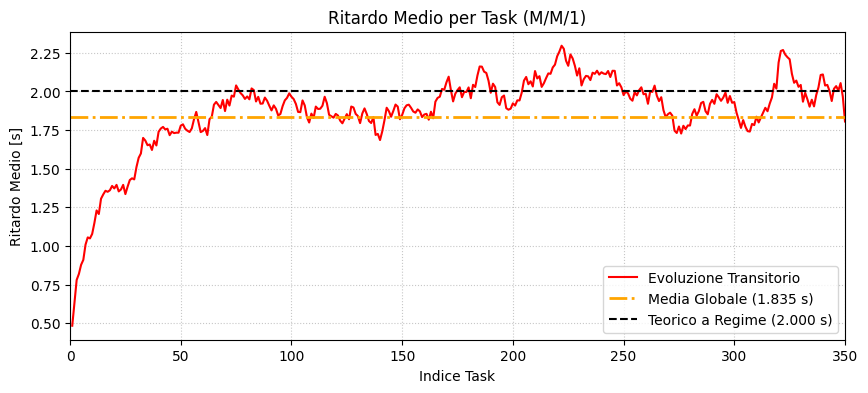

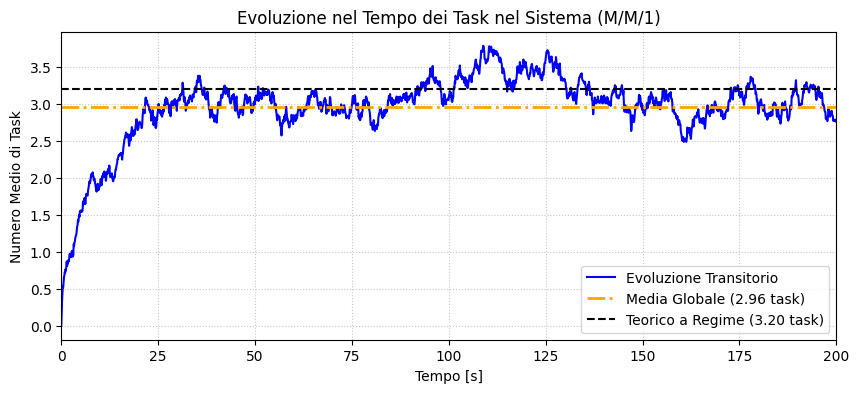

In [39]:
# ==========================================
# ESECUZIONE SIMULATORE: ENSEMBLE AVERAGE
# ==========================================

# 1. Definizione dei parametri fisici
params = {'L': 1e6, 'C': 1e8, 'D_max': 0.5} 
lambda_test = 2.0 
f_loc_test = 2.5*1e8 

# Calcolo del tasso di servizio per le linee teoriche (mu = 1e9 / 1e8 = 10 task/s)
mu_rate = f_loc_test / params['C']
rho = lambda_test / mu_rate
print("Parametri di Simulazione:")
print(f"  - Lambda (tasso di arrivo): {lambda_test:.2f} task/s")
print(f"  - F_loc (frequenza di servizio): {f_loc_test:.2e} Hz")
print(f"  - Mu (tasso di servizio): {mu_rate:.2f} task/s")   

print(f"Avvio Simulazione... Carico teorico (rho): {lambda_test/mu_rate:.0%}")

# 2. Lancio delle 50 repliche indipendenti
# (Ricorda: la funzione restituisce 5 elementi, usiamo '_' per ignorare la matrice grezza se non ci serve)
t_grid, a_queue, a_util, a_delay, all_delays = run_multiple_sims(
    num_runs=150, 
    tasks_to_complete=500, 
    time_limit=200.0, 
    lambda_rate=lambda_test, 
    f_loc=f_loc_test, 
    params_Ks=params
)

print("Simulazioni completate! Generazione dei grafici...")

# 3. Plotting dei risultati con le baselines teoriche
plot_avg_delay(a_delay, lambda_test, mu_rate, zoom_tasks=350)  # Zoom sui primi 200 task per vedere meglio il transitorio
plot_avg_queue(t_grid, a_queue, lambda_test, mu_rate, zoom_time=200)  # Zoom sui primi 200 secondi per vedere meglio il transitorio



## 1.b

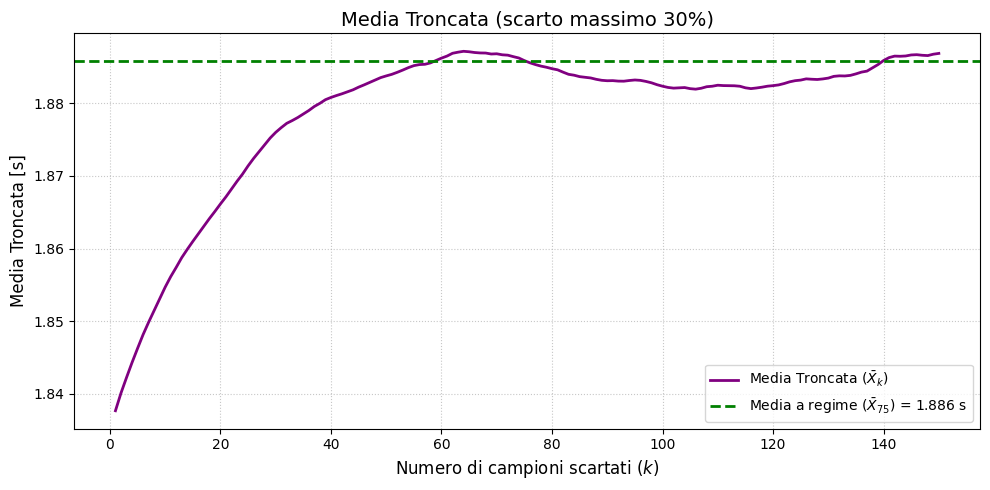

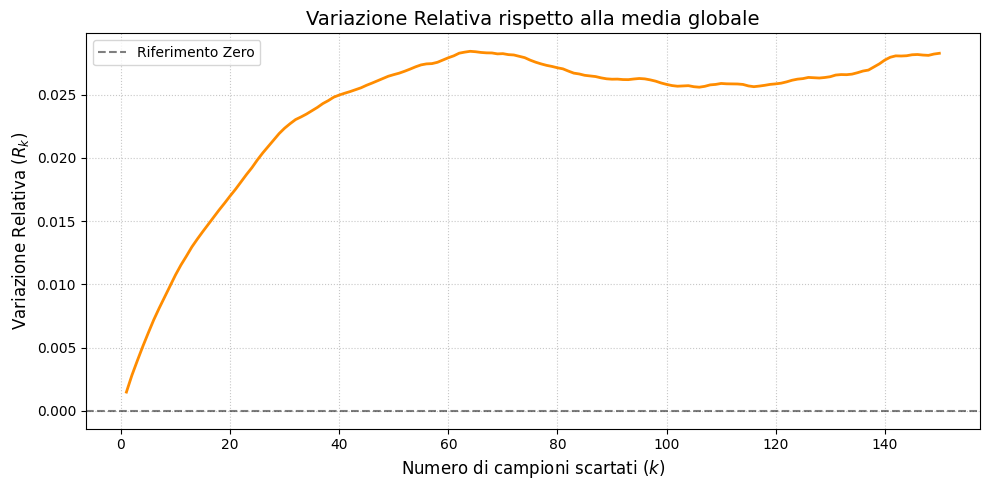

In [40]:
analyze_warmup(a_delay, max_discard_percent=0.3, k_star=75)

## 1.C

In [45]:
lambdas = [0.5, 1.0, 1.5, 2.0, 2.25]
results = []
mu = f_loc_test / params['C']  # Tasso di servizio basato sui parametri
k_star = 75  # Numero di task da scartare per il warm-up (da analisi precedente)
for lmb in lambdas:
        print(f"\n--- Analisi per Lambda = {lmb} (Rho = {lmb/2.5:.2f}) ---")
        
        # Lanciamo la simulazione pesante, spacchettando TUTTI e 5 i valori
        t_grid, a_queue, a_util, a_delay, matrice_grezza = run_multiple_sims(
            num_runs=525, 
            tasks_to_complete=500, 
            time_limit=200.0, 
            lambda_rate=lmb, 
            f_loc=2.5*1e8, 
            params_Ks=params,
            alpha=1.0 # o i tuoi eventuali altri parametri
        )
        # Analisi statistica a regime passando la MATRICE 2D
        mean_d, lb_d, ub_d = perform_statistical_analysis(matrice_grezza, k_star=k_star)
        t_warmup = k_star / lmb
        warmup_index = np.searchsorted(t_grid, t_warmup)
        steady_state_queue = np.mean(a_queue[warmup_index:])  # Media a regime escludendo il warm-up
        results.append({
            'lambda': lmb,
            'mean_delay': mean_d,
            'lb_delay': lb_d,
            'ub_delay': ub_d,
            'mean_queue': steady_state_queue
        })


--- Analisi per Lambda = 0.5 (Rho = 0.20) ---
----------------------------------------
RISULTATI ANALISI STATISTICA (A REGIME)
----------------------------------------
Repliche indipendenti: 525
Warm-up rimosso:       75 task
Media stimata:         0.4999 s
Intervallo Conf.95%: [0.4967, 0.5031] s
Margine di errore:     ±0.0032 s
----------------------------------------

--- Analisi per Lambda = 1.0 (Rho = 0.40) ---
----------------------------------------
RISULTATI ANALISI STATISTICA (A REGIME)
----------------------------------------
Repliche indipendenti: 525
Warm-up rimosso:       75 task
Media stimata:         0.6663 s
Intervallo Conf.95%: [0.6601, 0.6725] s
Margine di errore:     ±0.0062 s
----------------------------------------

--- Analisi per Lambda = 1.5 (Rho = 0.60) ---
----------------------------------------
RISULTATI ANALISI STATISTICA (A REGIME)
----------------------------------------
Repliche indipendenti: 525
Warm-up rimosso:       75 task
Media stimata:         0.99

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_50180/3959779448.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Tasso di arrivo $\lambda$ [task/s]", fontsize=12)


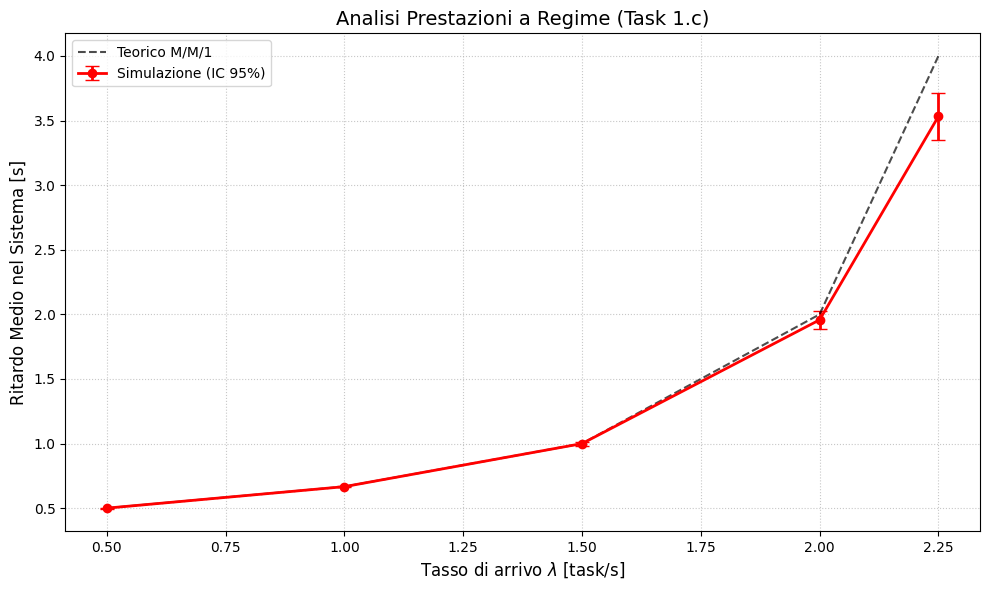

In [46]:
# 4. PLOTTING DELLA CURVA DI CARICO
lmb_vals = [r['lambda'] for r in results]
mean_delays = [r['mean_delay'] for r in results]
lb_vals = [r['lb_delay'] for r in results]
ub_vals = [r['ub_delay'] for r in results]

# Calcolo errori per la barra di errore
lower_error = np.array(mean_delays) - np.array(lb_vals)
upper_error = np.array(ub_vals) - np.array(mean_delays)

plt.figure(figsize=(10, 6))
# I tuoi dati simulati con l'intervallo di confidenza
plt.errorbar(lmb_vals, mean_delays, yerr=[lower_error, upper_error], 
             fmt='o-', color='red', capsize=5, label='Simulazione (IC 95%)', linewidth=2)

# La curva teorica M/M/1 (Ritardo E[T] = 1 / (mu - lambda))
teorico = [1 / (mu - l) for l in lmb_vals]
plt.plot(lmb_vals, teorico, 'k--', label='Teorico M/M/1', alpha=0.7)

plt.title("Analisi Prestazioni a Regime (Task 1.c)", fontsize=14)
plt.xlabel("Tasso di arrivo $\lambda$ [task/s]", fontsize=12)
plt.ylabel("Ritardo Medio nel Sistema [s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_50180/484229162.py:16: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Tasso di arrivo $\lambda$ [task/s]", fontsize=12)


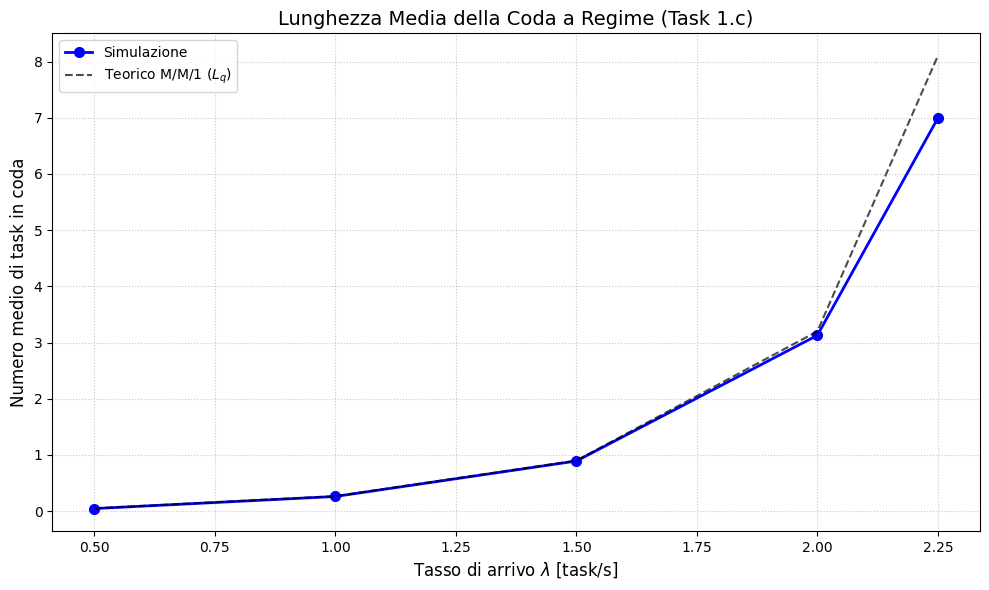

In [48]:
# Estrazione dati della coda dai risultati già calcolati
mean_queues = [r['mean_queue'] for r in results]
rhos = [lmb / mu for lmb in lmb_vals]

plt.figure(figsize=(10, 6))

# Plot dei dati simulati
plt.plot(lmb_vals, mean_queues, 'o-', color='blue', label='Simulazione', linewidth=2, markersize=7)

# Calcolo e plot della curva teorica M/M/1 (Lunghezza della coda d'attesa)
# Formula: Lq = rho^2 / (1 - rho)
teorico_coda = [(r**2) / (1 - r) for r in rhos]
plt.plot(lmb_vals, teorico_coda, 'k--', label='Teorico M/M/1 ($L_q$)', alpha=0.7)

plt.title("Lunghezza Media della Coda a Regime (Task 1.c)", fontsize=14)
plt.xlabel("Tasso di arrivo $\lambda$ [task/s]", fontsize=12)
plt.ylabel("Numero medio di task in coda", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()